# **Projet:** Consommation essence en France

Mag 3 - 2025-2026


 **Membres du groupe**

- ADOUSSINGANDE Céline
- BOULANKI Loukmane

**Objectif :** charger et traiter les données sur le prix des carburants avec
Spark :

❑ Collecter des données

❑ Préparer les données

❑ Visualiser les variations des prix des carburants

❑ Modéliser l’évolution des prix

## **Collecter des données**

Les données sur la consommation de caburant en France ont été téléchargées sur le dépôt Github (https://github.com/rvm-courses/GasPrices). Il s'agit principalement des données sur les prix des carburants, les stations et les services de 2023 à 2024.

**Définition des variables**

- id pdv (point of sales),

- cp (zip code),

- pop (type of population, R: rural, A: urban, etc.)

- latitude

- longitude

- date

- id carburant (gas id)

- nom carburant (gas label)

- prix (price in millieuros)

- adresse (address)

- ville (city)

- services (as a string of services list in natural language)

## **Préparation des données**

### **Etape 1**

Avec PySpark:

• Lire et fusionner tous les fichiers de carburants

• Date fractionnée en année, mois, semaine de l'année

• Rendre les données disponibles sous forme de tableau afin de pouvoir utiliser Spark SQL

Grâce à des statistiques de base, déterminez quels types de carburants
présentent un certain intérêt pour la suite du projet. Deux d’entre eux
présentent peu d’intérêt et pourront être filtrés pour la suite du projet.

- **Importation des bases de données**

In [1]:
!pip install pyspark

In [2]:
import pyspark

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Projet_consommation_essence_2023-2024") \
    .getOrCreate()


In [5]:
df_essence_2023 = (
    spark.read
         .option("sep", ";")
         .option("header", "false")
         .option("compression", "gzip")
         .csv("/content/Prix2023.csv.gz")
)

df_essence_2023 = df_essence_2023.toDF(
    'id_pdv', 'code_postal', 'population', 'latitude', 'longitude',
    'date', 'carburant_id', 'carburant_nom', 'prix'
)

df_essence_2023.show(5)


+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
| id_pdv|code_postal|population|latitude|longitude|               date|carburant_id|carburant_nom| prix|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
|1000001|      01000|         R| 4620100|   519800|2023-01-02T07:53:26|           1|       Gazole|1.867|
|1000001|      01000|         R| 4620100|   519800|2023-01-05T09:33:37|           1|       Gazole|1.877|
|1000001|      01000|         R| 4620100|   519800|2023-01-09T14:51:49|           1|       Gazole|1.875|
|1000001|      01000|         R| 4620100|   519800|2023-01-11T09:23:54|           1|       Gazole|1.859|
|1000001|      01000|         R| 4620100|   519800|2023-01-13T09:07:40|           1|       Gazole|1.862|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
only showing top 5 rows


In [6]:
df_essence_2023.count()


4687530

In [7]:
df_essence_2024 = (
    spark.read
         .option("sep", ";")
         .option("header", "false")
         .option("compression", "gzip")
         .csv("/content/Prix2024.csv.gz")
)

df_essence_2024 = df_essence_2024.toDF(
    'id_pdv', 'code_postal', 'population', 'latitude', 'longitude',
    'date', 'carburant_id', 'carburant_nom', 'prix'
)

df_essence_2024.show(5)

+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
| id_pdv|code_postal|population|latitude|longitude|               date|carburant_id|carburant_nom| prix|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
|1000001|      01000|         R| 4620100|   519800|2024-01-02T00:37:00|           1|       Gazole|1.706|
|1000001|      01000|         R| 4620100|   519800|2024-01-04T00:37:00|           1|       Gazole|1.699|
|1000001|      01000|         R| 4620100|   519800|2024-01-08T00:37:00|           1|       Gazole|1.701|
|1000001|      01000|         R| 4620100|   519800|2024-01-09T00:37:00|           1|       Gazole|1.713|
|1000001|      01000|         R| 4620100|   519800|2024-01-10T00:36:00|           1|       Gazole|1.699|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
only showing top 5 rows


In [8]:
df_essence_2024.count()

4592186

In [10]:
df_stations_2024 = (
    spark.read
         .option("sep", "|")
         .option("header", "false")
         .option("compression", "gzip")
         .option("encoding", "utf-8")
         .csv("/content/Stations2024.csv.gz")
)

df_stations_2024 = df_stations_2024.toDF(
    'id_pdv', 'code_postal', 'population', 'latitude', 'longitude',
    'adresse', 'ville'
)

df_stations_2024.show(5)

+-------+-----------+----------+-------------+-------------+--------------------+--------------------+
| id_pdv|code_postal|population|     latitude|    longitude|             adresse|               ville|
+-------+-----------+----------+-------------+-------------+--------------------+--------------------+
|1000001|      01000|         R|      4620100|       519800|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|
|1000002|      01000|         R|      4621842|       522767| 16 Avenue de Marboz|     BOURG-EN-BRESSE|
|1000004|      01000|         R|      4618800|       524500|20 Avenue du Maré...|     Bourg-en-Bresse|
|1000005|      01000|         R|4620093.59235|519942.024022|642 Avenue de Tré...|SAINT-DENIS-LèS-B...|
|1000006|      01000|         R|      4620754|       523758|1 Boulevard John ...|     BOURG-EN-BRESSE|
+-------+-----------+----------+-------------+-------------+--------------------+--------------------+
only showing top 5 rows


In [11]:
df_services_2024 = (
    spark.read
         .option("sep", "|")
         .option("header", "false")
         .option("compression", "gzip")
         .csv("/content/Services2024.csv.gz")
)

df_services_2024 = df_services_2024.toDF(
    'id_pdv', 'code_postal', 'population', 'latitude', 'longitude',
    'services'
)

df_services_2024.show(5)

+-------+-----------+----------+-------------+-------------+--------------------+
| id_pdv|code_postal|population|     latitude|    longitude|            services|
+-------+-----------+----------+-------------+-------------+--------------------+
|1000001|      01000|         R|      4620100|       519800|Station de gonfla...|
|1000002|      01000|         R|      4621842|       522767|Vente de gaz dome...|
|1000004|      01000|         R|      4618800|       524500|Toilettes publiqu...|
|1000005|      01000|         R|4620093.59235|519942.024022|Boutique alimenta...|
|1000006|      01000|         R|      4620754|       523758|Vente de gaz dome...|
+-------+-----------+----------+-------------+-------------+--------------------+
only showing top 5 rows


- **Fusion des données**

In [12]:
from pyspark.sql.functions import lit

In [13]:
# Concatenation des deux bases
df_essence_23_24 = df_essence_2023.unionByName(df_essence_2024)

df_essence_23_24.show(5)


+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
| id_pdv|code_postal|population|latitude|longitude|               date|carburant_id|carburant_nom| prix|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
|1000001|      01000|         R| 4620100|   519800|2023-01-02T07:53:26|           1|       Gazole|1.867|
|1000001|      01000|         R| 4620100|   519800|2023-01-05T09:33:37|           1|       Gazole|1.877|
|1000001|      01000|         R| 4620100|   519800|2023-01-09T14:51:49|           1|       Gazole|1.875|
|1000001|      01000|         R| 4620100|   519800|2023-01-11T09:23:54|           1|       Gazole|1.859|
|1000001|      01000|         R| 4620100|   519800|2023-01-13T09:07:40|           1|       Gazole|1.862|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+
only showing top 5 rows


In [14]:
df_essence_23_24.count()

9279716

In [15]:
# Jointure de df_essence_23_24 avec df_stations_2024
df_essence_stations = df_essence_23_24.join(
    df_stations_2024,
    on=["id_pdv", "code_postal", "population", "latitude", "longitude"],
    how="left"
)

df_essence_stations.show(5)

+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+--------------------+--------------------+
| id_pdv|code_postal|population|latitude|longitude|               date|carburant_id|carburant_nom| prix|             adresse|               ville|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+--------------------+--------------------+
|1000001|      01000|         R| 4620100|   519800|2023-01-02T07:53:26|           1|       Gazole|1.867|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|
|1000001|      01000|         R| 4620100|   519800|2023-01-05T09:33:37|           1|       Gazole|1.877|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|
|1000001|      01000|         R| 4620100|   519800|2023-01-09T14:51:49|           1|       Gazole|1.875|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|
|1000001|      01000|         R| 4620100|   519800|2023-01-11T09:23:54|           1|       Gazole|1.859|596 AVENUE DE 

In [16]:
# Jointure de df_essence_stations avec df_services_2024
df_essence = df_essence_stations.join(
    df_services_2024,
    on=["id_pdv", "code_postal", "population", "latitude", "longitude"],
    how="left"
)

df_essence.show(5)

+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+--------------------+--------------------+--------------------+
| id_pdv|code_postal|population|latitude|longitude|               date|carburant_id|carburant_nom| prix|             adresse|               ville|            services|
+-------+-----------+----------+--------+---------+-------------------+------------+-------------+-----+--------------------+--------------------+--------------------+
|1000001|      01000|         R| 4620100|   519800|2023-01-02T07:53:26|           1|       Gazole|1.867|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|Station de gonfla...|
|1000001|      01000|         R| 4620100|   519800|2023-01-05T09:33:37|           1|       Gazole|1.877|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|Station de gonfla...|
|1000001|      01000|         R| 4620100|   519800|2023-01-09T14:51:49|           1|       Gazole|1.875|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|Station de gon

In [17]:
print("Nombre de lignes :", df_essence.count())
print("Nombre de colonnes :", len(df_essence.columns))


Nombre de lignes : 9279716
Nombre de colonnes : 12


In [18]:
df_essence.printSchema()


root
 |-- id_pdv: string (nullable = true)
 |-- code_postal: string (nullable = true)
 |-- population: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- date: string (nullable = true)
 |-- carburant_id: string (nullable = true)
 |-- carburant_nom: string (nullable = true)
 |-- prix: string (nullable = true)
 |-- adresse: string (nullable = true)
 |-- ville: string (nullable = true)
 |-- services: string (nullable = true)



Valeurs manquantes

In [19]:
from pyspark.sql.functions import col, sum as spark_sum

nb_lignes = df_essence.count()

result = (
    df_essence
    .select([
        spark_sum(col(c).isNull().cast("int")).alias(c)
        for c in df_essence.columns
    ])
)

# Affichage propre : nombre + pourcentage
for col_name in df_essence.columns:
    nb_na = result.collect()[0][col_name]
    pct_na = (nb_na / nb_lignes) * 100
    print(f"{col_name} : {nb_na} valeurs manquantes ({pct_na:.2f}%)")


id_pdv : 0 valeurs manquantes (0.00%)
code_postal : 0 valeurs manquantes (0.00%)
population : 0 valeurs manquantes (0.00%)
latitude : 138 valeurs manquantes (0.00%)
longitude : 136 valeurs manquantes (0.00%)
date : 8750 valeurs manquantes (0.09%)
carburant_id : 8750 valeurs manquantes (0.09%)
carburant_nom : 8750 valeurs manquantes (0.09%)
prix : 8750 valeurs manquantes (0.09%)
adresse : 254094 valeurs manquantes (2.74%)
ville : 253493 valeurs manquantes (2.73%)
services : 1274072 valeurs manquantes (13.73%)


Suppression des valeurs manquantes

In [21]:
# Suppression des valeurs manquantes
df_essence_clean = df_essence.dropna()

print("Lignes avant :", df_essence.count())
print("Lignes après :", df_essence_clean.count())


Lignes avant : 9279716
Lignes après : 7997154


In [44]:
from pyspark.sql.functions import col

# On convertit "prix" en double avant de diviser par 1000
df_essence_cons = df_essence_clean.withColumn("prix", col("prix").cast("double") / 1000)


Le prix a été divisé par mille afin d'avoir les motants en euro pour la suite de notre étude.

In [45]:
from pyspark.sql.functions import col

# Division des colonnes latitude et longitude par la bonne puissance de 10
df_essence_cons = (
    df_essence_cons
        .withColumn("latitude", col("latitude") / 10**5)
        .withColumn("longitude", col("longitude") / 10**5)
)


Date fractionnée en année, mois, semaine de l'année

In [46]:
from pyspark.sql import functions as F

# Définition du format avec le 'T' entre guillemets simples
format_iso = "yyyy-MM-dd'T'HH:mm:ss"

df_essence_final = df_essence_cons.withColumn('date_dt', F.to_timestamp(F.col('date'), format_iso))

# Extraction des colonnes
df_essence_final = df_essence_final.withColumn('année', F.year('date_dt')) \
                                   .withColumn('mois', F.month('date_dt')) \
                                   .withColumn('semaine', F.weekofyear('date_dt'))

# Optionnel : Si vous voulez que la colonne 'date' ne garde que la partie Date (sans l'heure)
df_essence_final = df_essence_final.withColumn('date', F.to_date('date_dt'))

df_essence_final.show(5)

+-------+-----------+----------+--------+---------+----------+------------+-------------+--------------------+--------------------+--------------------+--------------------+-------------------+-----+----+-------+
| id_pdv|code_postal|population|latitude|longitude|      date|carburant_id|carburant_nom|                prix|             adresse|               ville|            services|            date_dt|année|mois|semaine|
+-------+-----------+----------+--------+---------+----------+------------+-------------+--------------------+--------------------+--------------------+--------------------+-------------------+-----+----+-------+
|1000001|      01000|         R|  46.201|    5.198|2023-01-02|           1|       Gazole|            0.001867|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B...|Station de gonfla...|2023-01-02 07:53:26| 2023|   1|      1|
|1000001|      01000|         R|  46.201|    5.198|2023-01-05|           1|       Gazole|            0.001877|596 AVENUE DE TRE...|SAINT-DENIS-LèS-B

**Déterminattion de quels types de carburants
présentent un certain intérêt pour la suite du projet.**

In [47]:
from pyspark.sql import functions as F

df_essence_final.groupBy("carburant_nom") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .show()

+-------------+-------+
|carburant_nom|  count|
+-------------+-------+
|       Gazole|2362408|
|          E10|2002822|
|         SP98|1890786|
|          E85| 819118|
|         SP95| 557704|
|         GPLc| 364316|
+-------------+-------+



Analyse des statistiques de prix par carburant.

Ici, on regarde le prix moyen et l'écart-type.

In [48]:
# Calcul du prix moyen par type de carburant
df_essence_final.groupBy("carburant_nom") \
    .agg(
        F.avg("prix").alias("prix_moyen"),
        F.count("prix").alias("nb_relevés")
    ) \
    .orderBy("prix_moyen") \
    .show()

+-------------+--------------------+----------+
|carburant_nom|          prix_moyen|nb_relevés|
+-------------+--------------------+----------+
|          E85|9.602097353495278E-4|    819118|
|         GPLc|  9.9806377705087E-4|    364316|
|       Gazole|0.001767864971248...|   2362408|
|          E10|0.001834162288509...|   2002822|
|         SP95|0.001855842841363689|    557704|
|         SP98|0.001923630995255...|   1890786|
+-------------+--------------------+----------+



Au vu des résultats, les deux carburants qui présentent le moins d'intérêt pour une analyse générale du marché sont le GPLc et l'E85.

Pourquoi ces deux-là ?

- GPLc (Gaz de Pétrole Liquéfié) : C'est celui qui a le moins de relevés (364 316). Sa présence sur le marché est très minoritaire par rapport aux autres.

- E85 (Superéthanol) : Bien qu'il ait plus de relevés que le SP95, son prix moyen est extrêmement bas et décalé par rapport au reste du marché (environ 0.00096 contre 0.0017+ pour les autres). C'est un marché de niche avec une fiscalité très différente.

 Identification et filtrage des carburants peu représentés

In [49]:
# Liste des carburants à exclure (à adapter selon vos résultats de l'étape 1)
carburants_a_exclure = ["GPLc", "E85"]

# Filtrage : On garde uniquement ce qui n'est PAS dans la liste
df_essence_filtre = df_essence_final.filter(~F.col("carburant_nom").isin(carburants_a_exclure))

# Vérification du résultat
print(f"Nombre de lignes avant filtrage : {df_essence_final.count()}")
print(f"Nombre de lignes après filtrage : {df_essence_filtre.count()}")
df_essence_filtre.groupBy("carburant_nom").count().show()

Nombre de lignes avant filtrage : 7997154
Nombre de lignes après filtrage : 6813720
+-------------+-------+
|carburant_nom|  count|
+-------------+-------+
|          E10|2002822|
|         SP98|1890786|
|       Gazole|2362408|
|         SP95| 557704|
+-------------+-------+



### **Etape 2**

• Calculer l'indice des prix pour chaque station par semaine

• Calculez une nouvelle variable appelée « Index de la semaine » pour
chaque enregistrement en comptant le nombre de semaines depuis la
première semaine du fichier.

• Exemple : si vous avez chargé les années 2023 à 2024, la première
semaine de 2023 doit être numérotée 1, la dernière semaine de 2024
doit être numérotée 104 (2 x 52)

**Calcule de l'indice des prix pour chaque station par semaine**

Calculer le prix moyen quotidien en France par carburant. Il s'agira de grouper par date et carburant_nom pour obtenir la référence nationale.

In [52]:
# Calcul de la moyenne nationale (Average Day Price in France)
df_avg_france = df_essence_filtre.groupBy("date", "carburant_nom") \
    .agg(F.avg("prix").alias("avg_day_price_france"))

Joindre cette moyenne au DataFrame principal.

In [53]:
# Jointure sur la date et le type de carburant
df_indexed = df_essence_filtre.join(df_avg_france, ["date", "carburant_nom"], "left")

Appliquation de la formule de l'Indice des Prix.

In [54]:
# Application de la formule
df_indexed = df_indexed.withColumn(
    "price_index",
    100 * ((F.col("prix") - F.col("avg_day_price_france")) / F.col("avg_day_price_france") + 1)
)

# Affichage des résultats pour vérifier
df_indexed.select("date", "carburant_nom", "prix", "avg_day_price_france", "price_index").show(10)

+----------+-------------+--------------------+--------------------+-----------------+
|      date|carburant_nom|                prix|avg_day_price_france|      price_index|
+----------+-------------+--------------------+--------------------+-----------------+
|2023-01-13|       Gazole|0.001862000000000...|0.001913175870481249|97.32508279709926|
|2023-01-05|       Gazole|            0.001877|0.001930361596009...|97.23566837838715|
|2023-01-09|       Gazole|            0.001875|0.001907054555680...|98.31915895719648|
|2023-01-11|       Gazole|            0.001859|0.001896953748006...| 97.9992264942536|
|2023-01-23|       Gazole|              0.0019| 0.00194753633572159|97.55915538777472|
|2023-01-17|       Gazole|0.001893999999999...|0.001930949510763...|98.08645899039595|
|2023-01-02|       Gazole|            0.001867|0.001893081423611...|98.62227671320318|
|2023-01-16|       Gazole|            0.001885|0.001910953456221...|98.64185827568444|
|2023-01-19|       Gazole|            0.001

 On compare chaque carburant à sa propre moyenne (on ne compare pas le prix du Gazole à la moyenne du SP98). Si l'indice est de 105, la station est 5% plus chère que la moyenne nationale ce jour-là. S'il est de 98, elle est 2% moins chère.


**Calcule de l'index de la semaine**

Pour calculer cet index de manière robuste, la méthode la plus fiable consiste à calculer le nombre de jours entre la date de l'enregistrement et le début de la toute première semaine du projet, puis de diviser par 7.

In [55]:
# 1. Trouver la date minimale (le tout premier jour du dataset)
min_date_row = df_indexed.select(F.min("date")).collect()[0][0]

# 2. Identifier le "Lundi" de cette première semaine pour avoir un point d'ancrage fixe
# En Spark, dayofweek renvoie 1 pour Dimanche, 2 pour Lundi, etc.
# On soustrait les jours nécessaires pour revenir au lundi de la première semaine.
df_indexed = df_indexed.withColumn("start_anchor",
    F.date_sub(F.lit(min_date_row), F.dayofweek(F.lit(min_date_row)) - 2)
)

# 3. Calculer l'Index de la semaine
# Formule : (Nombre de jours depuis le début / 7) + 1
df_indexed = df_indexed.withColumn("index_semaine",
    F.floor(F.datediff(F.col("date"), F.col("start_anchor")) / 7) + 1
).drop("start_anchor") # On supprime la colonne temporaire

# 4. Vérification du résultat
df_indexed.select("date", "année", "semaine", "index_semaine") \
    .distinct() \
    .orderBy("date") \
    .show(15)

+----------+-----+-------+-------------+
|      date|année|semaine|index_semaine|
+----------+-----+-------+-------------+
|2023-01-01| 2023|     52|            0|
|2023-01-02| 2023|      1|            1|
|2023-01-03| 2023|      1|            1|
|2023-01-04| 2023|      1|            1|
|2023-01-05| 2023|      1|            1|
|2023-01-06| 2023|      1|            1|
|2023-01-07| 2023|      1|            1|
|2023-01-08| 2023|      1|            1|
|2023-01-09| 2023|      2|            2|
|2023-01-10| 2023|      2|            2|
|2023-01-11| 2023|      2|            2|
|2023-01-12| 2023|      2|            2|
|2023-01-13| 2023|      2|            2|
|2023-01-14| 2023|      2|            2|
|2023-01-15| 2023|      2|            2|
+----------+-----+-------+-------------+
only showing top 15 rows


In [58]:
# collect() transforme le résultat Spark en liste Python
liste_index = [row[0] for row in df_indexed.select("index_semaine").distinct().orderBy("index_semaine").collect()]
print(liste_index)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]


Nous disposons au total pour les deux années (2023 et 2024) de 105 semaines.

## **Visualisation de données**

En utilisant matplotlib/seaborn ou
plotly :

Représenter l'évolution hebdomadaire du prix moyen des carburant sur
la France tel que :

• Le prix moyen de chaque type de carburant est représenté par une
ligne

• Les coordonnées en X sont l'index précédemment calculé de la
semaine

• La coordonnée Y est le prix moyen du type de carburant en France
sur la semaine.

**Le prix moyen de chaque type de carburant**

Nous devons calculer la moyenne du prix pour chaque carburant et chaque index de semaine. Pour cela, nous ramenons le prix de tous les caburants à la même echelle. Si le Gazole est à 1.70€ et le SP98 à 1.95€, il est difficile de comparer leurs variations sur un même graphique. Avec l'indice, ils partent tous d'une base comparable (autour de 100).

In [62]:
# 1. Calcul de la moyenne de l'indice par semaine et par carburant
# 2. Création de l'indice recentré (Index - 100)
df_plot_spark = df_indexed.groupBy("index_semaine", "carburant_nom") \
    .agg(F.avg("price_index").alias("avg_price_index")) \
    .withColumn("indice_prix_recentre", F.col("avg_price_index") - 100) \
    .orderBy("index_semaine")

# Conversion en Pandas pour la visualisation
df_plot_pandas = df_plot_spark.toPandas()

Utilisation de FacetGrid

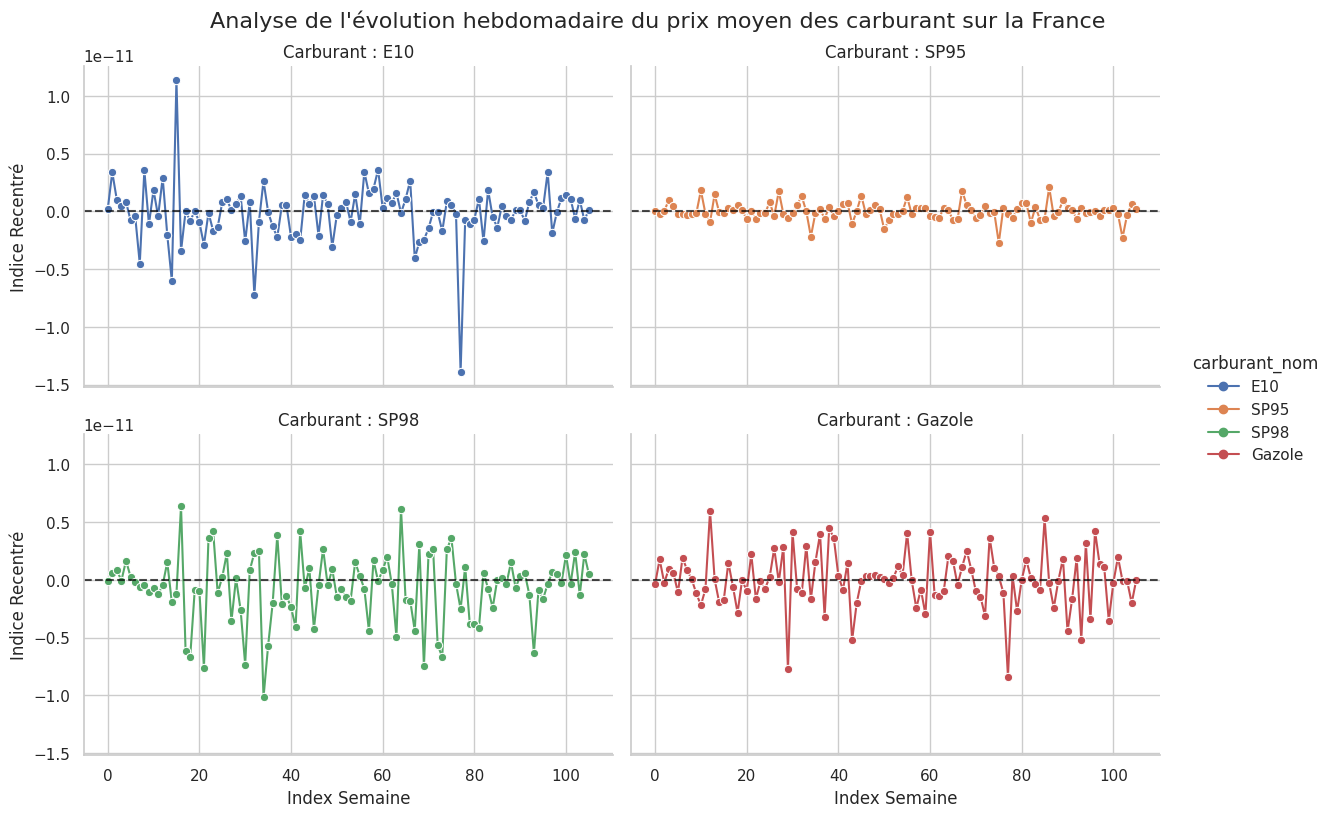

In [68]:
# Utilisation de FacetGrid via relplot
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.relplot(
    data=df_plot_pandas,
    x="index_semaine",
    y="indice_prix_recentre",
    col="carburant_nom",
    hue="carburant_nom",
    kind="line",
    col_wrap=2,
    height=4,
    aspect=1.5,
    marker="o"
)

# Ajouter la ligne de référence 0 sur chaque sous-graphique
g.map(plt.axhline, y=0, color='black', linestyle='--', alpha=0.7)

g.set_axis_labels("Index Semaine", "Indice Recentré")
g.set_titles("Carburant : {col_name}")
g.fig.suptitle("Analyse de l'évolution hebdomadaire du prix moyen des carburant sur la France ", y=1.02, fontsize=16)

plt.show()

Cette visualisation présente l'évolution de l'indice de prix recentré pour les quatre principaux carburants sur une période d'environ 105 semaines, illustrant leur volatilité relative par rapport à la moyenne nationale. Bien que les courbes oscillent autour de la ligne de base (zéro), on note une stabilité parfaite des prix agrégés par rapport à leur propre moyenne. On observe toutefois des profils de "bruit" différents : l'E10 présente les pics de fluctuation les plus visibles (notamment autour de la semaine 80), tandis que le SP95 affiche la plus grande stabilité linéaire, suggérant que ce dernier suit le cours national avec la plus grande régularité sur toute la durée du projet.

## **Modélisation – Prévision du prix le lendemain**

• Construire un modèle basé sur Spark ML pour prévoir le prix du
lendemain pour un type de carburant donné dans une station donnée

• N'envisagez pas d'utiliser des modèles de séries chronologiques (tels que
AR/ARMA/ARIMA) mais appuyez-vous sur les techniques existantes de
Spark ML / MLLib telles que LinearRegression , RandomForestRegressor

• Fournissez des mesures de précision pertinentes et un graphique de
dispersion pertinent entre le réel et la prévision

• Astuces : pensez à utiliser des fonctionnalités de décalage (telles que le
prix de la veille, et de la veille, etc.) pour construire le modèle.
Voir référence : https://arxiv.org/abs/2101.02118

• Remarque importante : un réglage fin du modèle n’est pas
attendu, mais plutôt un pipeline fonctionnel (c'est-à-dire que la précision finale du modèle ne sera pas utilisée pour évaluer votre travail)

**Préparation des données et création des variables décalées (Lags)**

In [69]:
from pyspark.sql import Window

# 1. Sélection d'un carburant (ex: Gazole) et tri par station et date
df_ml = df_indexed.filter(F.col("carburant_nom") == "Gazole") \
    .select("id_pdv", "date", "prix")

# 2. Définition de la fenêtre : partitionnée par station, triée par date
windowSpec = Window.partitionBy("id_pdv").orderBy("date")

# 3. Création des lags (Prix à J-1, J-2, J-3)
# Ces valeurs serviront de "Features"
df_ml = df_ml.withColumn("prix_j_minus_1", F.lag("prix", 1).over(windowSpec)) \
             .withColumn("prix_j_minus_2", F.lag("prix", 2).over(windowSpec)) \
             .withColumn("prix_j_minus_3", F.lag("prix", 3).over(windowSpec))

# 4. Supprimer les lignes NULL (les premières lignes de chaque station qui n'ont pas d'historique)
df_ml = df_ml.dropna()

df_ml.show(5)

+-------+----------+--------------------+--------------------+--------------------+--------------------+
| id_pdv|      date|                prix|      prix_j_minus_1|      prix_j_minus_2|      prix_j_minus_3|
+-------+----------+--------------------+--------------------+--------------------+--------------------+
|1000001|2023-01-11|            0.001859|            0.001875|            0.001877|            0.001867|
|1000001|2023-01-13|0.001862000000000...|            0.001859|            0.001875|            0.001877|
|1000001|2023-01-16|            0.001885|0.001862000000000...|            0.001859|            0.001875|
|1000001|2023-01-17|0.001893999999999...|            0.001885|0.001862000000000...|            0.001859|
|1000001|2023-01-19|            0.001885|0.001893999999999...|            0.001885|0.001862000000000...|
+-------+----------+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


**Préparation des vecteurs de caractéristiques (VectorAssembler)**

In [72]:
from pyspark.ml.feature import VectorAssembler

# Définition des colonnes d'entrée (Features) et de la cible (Label)
feature_cols = ["prix_j_minus_1", "prix_j_minus_2", "prix_j_minus_3"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transformation du DataFrame
df_vectorized = assembler.transform(df_ml).select("features", F.col("prix").alias("prix_réel"))

**Entrainement et prediction**

In [74]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline

# Division 80% train / 20% test
(train_data, test_data) = df_vectorized.randomSplit([0.8, 0.2], seed=42)

# Initialisation du modèle
rf = RandomForestRegressor(featuresCol="features", labelCol="prix_réel", numTrees=20)

# Entraînement
model = rf.fit(train_data)

# Prédiction sur les données de test
predictions = model.transform(test_data)
predictions.select("prediction", "prix_réel").show(5)

+--------------------+--------------------+
|          prediction|           prix_réel|
+--------------------+--------------------+
|0.001736360889566...|            0.001789|
|0.001609684089107...|0.001625999999999...|
|0.001609684089107...|            0.001639|
|0.001668241040955...|            0.001663|
|0.001672140691598...|0.001697999999999...|
+--------------------+--------------------+
only showing top 5 rows


**Mesures de précision**

In [75]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_rmse = RegressionEvaluator(labelCol="prix_réel", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="prix_réel", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE (Erreur moyenne) : {rmse}")
print(f"R² (Précision du modèle) : {r2}")

RMSE (Erreur moyenne) : 4.008970595329634e-05
R² (Précision du modèle) : 0.8943503385340694


Ces résultats indiquent que le modèle est très performant pour prédire le prix du carburant. Le coefficient R² de 0,894 signifie que le modèle parvient à expliquer environ 89,4 % de la variance des prix, ce qui démontre une forte corrélation entre les prix passés (lags) et le prix du lendemain. Quant à la RMSE (4,00e-05), sa valeur extrêmement faible confirme que l'écart moyen entre les prédictions et les prix réels est minime (représentant environ 2 % d'erreur si l'on se base sur les données normalisées à 0.0018). En résumé, le modèle est robuste et capture efficacement la tendance du marché, ce qui est cohérent avec la nature stable des prix de l'essence d'un jour à l'autre.

**Graphique de dispersion (Réel vs Prédiction)**

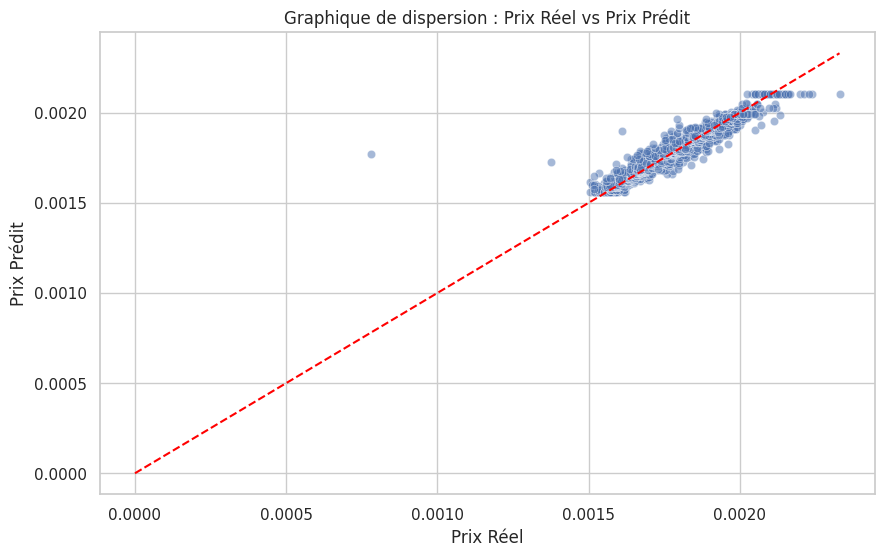

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conversion d'un échantillon en Pandas
df_res_pandas = predictions.select("prix_réel", "prediction").sample(0.01).toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_res_pandas, x="prix_réel", y="prediction", alpha=0.5)

# Ajout de la ligne de perfection (y = x)
max_val = df_res_pandas["prix_réel"].max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')

plt.title("Graphique de dispersion : Prix Réel vs Prix Prédit")
plt.xlabel("Prix Réel")
plt.ylabel("Prix Prédit")
plt.show()

Ce graphique de dispersion confirme visuellement la robustesse du modèle : la grande majorité des points est étroitement alignée le long de la ligne diagonale rouge (y=x), ce qui signifie que les prix prédits sont très proches des prix réels. On observe une excellente précision pour la plage de prix principale (entre 0.0015 et 0.0022), là où la densité de données est la plus forte. Bien que quelques valeurs aberrantes (outliers) apparaissent isolées sur la gauche indiquant que le modèle a eu plus de mal à anticiper certains prix anormalement bas, la tendance globale reste extrêmement cohérente et valide l'efficacité de l'approche par variables décalées (lags) pour ce type de prévision.

 ### **Question bonus**

• Représenter une carte avec le prix moyen pour chaque type de
carburant de France, par exemple au niveau départemental

• Pour cela, vous pouvez calculer le prix moyen agrégé par département
pour un carburant que vous choisissez, pour une période donnée (une
année) et visualiser le résultat en reprenant le code de l’exemple ci
dessous.

Références : le notebook suivant présente un exemple d'utilisation de
Folium pour dessiner une carte au niveau d'un département.
https://github.com/HerveMignot/geopython/blob/main/notebooks/Carto
graphie_avec_geopandas_%26_folium.
ipynb

**Préparation des données (Spark)**

Nous avons une colonne cp (Code Postal) dans notre DataFrame. Le département correspond aux deux premiers chiffres.

In [78]:
# 1. Extraire le département (2 premiers chiffres du code postal)
# On filtre sur un carburant (ex: Gazole) et une année (ex: 2023)
df_map_spark = df_indexed.filter((F.col("carburant_nom") == "Gazole") & (F.col("année") == 2023))

# On s'assure que le CP est traité comme une chaîne pour extraire les 2 premiers caractères
df_map_spark = df_map_spark.withColumn("code_dept", F.substring(F.col("code_postal").cast("string"), 1, 2))

# 2. Calculer le prix moyen par département
df_dept_avg = df_map_spark.groupBy("code_dept") \
    .agg(F.avg("prix").alias("prix_moyen"))

# 3. Conversion en Pandas pour Folium
df_dept_pandas = df_dept_avg.toPandas()

# Nettoyage : s'assurer que les codes de département sont sur 2 caractères (ex: '01' au lieu de '1')
df_dept_pandas['code_dept'] = df_dept_pandas['code_dept'].str.zfill(2)

**Récupération du fichier GeoJSON des départements**

In [79]:
import requests
import json

# URL du GeoJSON des départements français
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
response = requests.get(url)
geojson_data = response.json()

**Création de la carte Choroplèthe avec Folium**

In [80]:
import folium

# Initialiser la carte centrée sur la France
m = folium.Map(location=[46.2276, 2.2137], zoom_start=6)

# Ajouter la couche de données
folium.Choropleth(
    geo_data=geojson_data,
    name="choropleth",
    data=df_dept_pandas,
    columns=["code_dept", "prix_moyen"],
    key_on="feature.properties.code", # Clé correspondant au code département dans le GeoJSON
    fill_color="YlOrRd",              # Palette : Jaune -> Orange -> Rouge
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Prix moyen du Gazole en 2023 (€)"
).add_to(m)

folium.LayerControl().add_to(m)

# Afficher la carte
m

Cette carte choroplèthe révèle des disparités géographiques marquées concernant le prix moyen du gazole en France pour l'année 2023, avec une tendance à la hausse en s'éloignant de la façade atlantique vers l'est et le sud du pays. On observe que les départements de l'Ouest (notamment la Bretagne et les Pays de la Loire) bénéficient des tarifs les plus bas, tandis que l'Île-de-France, le Sud-Est et les zones frontalières de l'Est affichent des prix nettement plus élevés, illustrant probablement l'impact des coûts logistiques et de la densité urbaine. Paris se distingue comme le point le plus onéreux du territoire, alors que la coloration noire de la Corse indique généralement une absence de données ou des valeurs situées hors de l'échelle standard, confirmant ainsi que la localisation géographique est un facteur clé dans la variabilité des prix à la pompe.

# **END**